# **Identify customers at risk of churn and analyze the factors associated with customer attrition.**

# **Workflow Analysis**

1. Data Understanding
2. Data Cleaning
3. EDA
4. Feature Engineering
5. Feature Encoding
6. Train-Test Split
7. Baseline Modeling
8. Model Comparison
9. Hyperparameter Tuning
10. Model Evaluation
11. Model Interpretation
12. Churn Risk Segmentation
13. Business Insights

**Baseline Mode**l: Logistic Regression

**Model Comparison**: Logsitic Regression, XGBoost, Random Forest

## **1) Setup & Import Library**

In [91]:
!pip install -q xgboost shap

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance
import shap
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
file_path = "/content/drive/MyDrive/TELCO_DATASETS/telco_datasets.csv"

In [56]:
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **2) Data Understanding & Preprocessing**

In [57]:
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print("\nData types:")
display(df.dtypes)

Number of rows    : 7043
Number of columns : 21

Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [58]:
display(df.head())
display(df.tail())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [59]:
print("missing values:", df.isnull().sum())

missing values: customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [60]:
# cek duplicate data
print("number of duplicate rows:", df.duplicated().sum())

number of duplicate rows: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


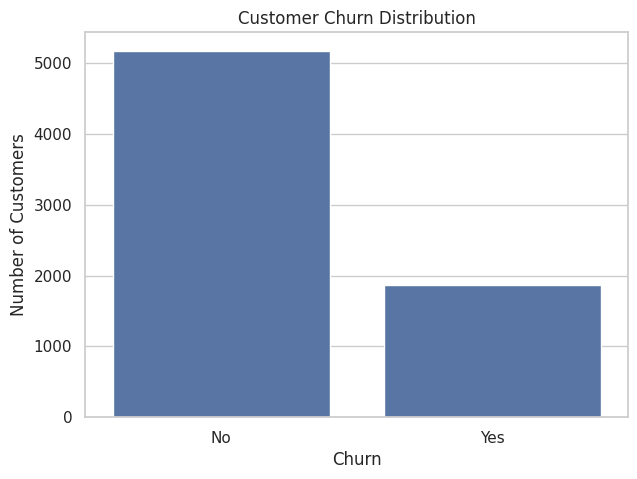

In [61]:
# target distribution

print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## **3) Data Cleaning**

In [62]:
df_clean = df.copy()

# remove unnecessary whitespace from object columns
object_columns = df_clean.select_dtypes(include="object").columns
for col in object_columns:
    df_clean[col] = df_clean[col].str.strip()

# convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)
print("missing values after conversion:")
display(
    df_clean.isnull().sum()
    .sort_values(ascending=False)
    .head(10)
)

missing values after conversion:


,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


In [63]:
# handle total charges

df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print(
    "missing TotalCharges:",
    df_clean["TotalCharges"].isnull().sum()
)

missing TotalCharges: 0


In [64]:
# remove id column
df_clean = df_clean.drop(columns=["customerID"])

print(df_clean.shape)

(7043, 20)


In [65]:
# target encoding for churn
df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

df_clean["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


## **4) EDA**

In [66]:
# 1) churn by contract
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


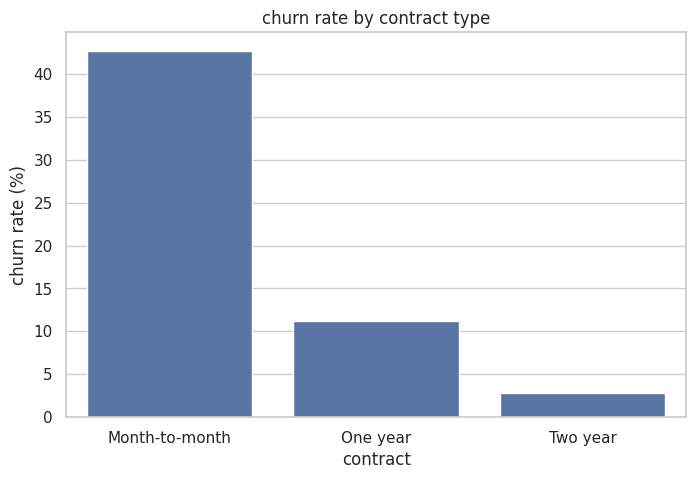

In [67]:
contract_rate = (
    df_clean
    .groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_rate.index,
    y=contract_rate.values
)

plt.title("churn rate by contract type")
plt.xlabel("contract")
plt.ylabel("churn rate (%)")
plt.show()

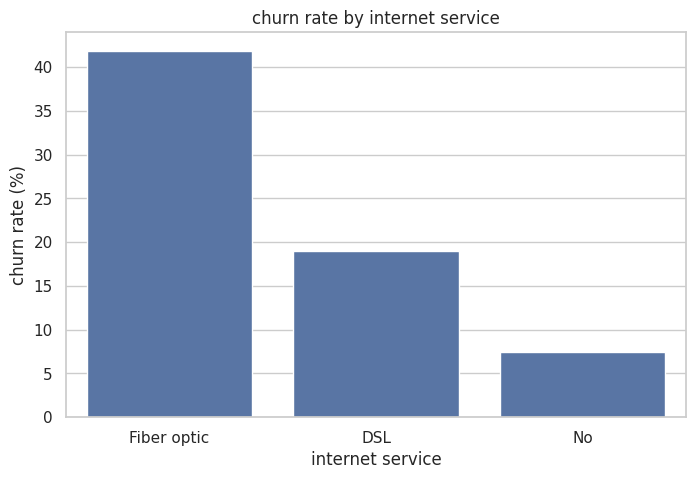

In [68]:
# 2) churn by internet service
internet_rate = (
    df_clean
    .groupby("InternetService")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_rate.index,
    y=internet_rate.values
)

plt.title("churn rate by internet service")
plt.xlabel("internet service")
plt.ylabel("churn rate (%)")
plt.show()

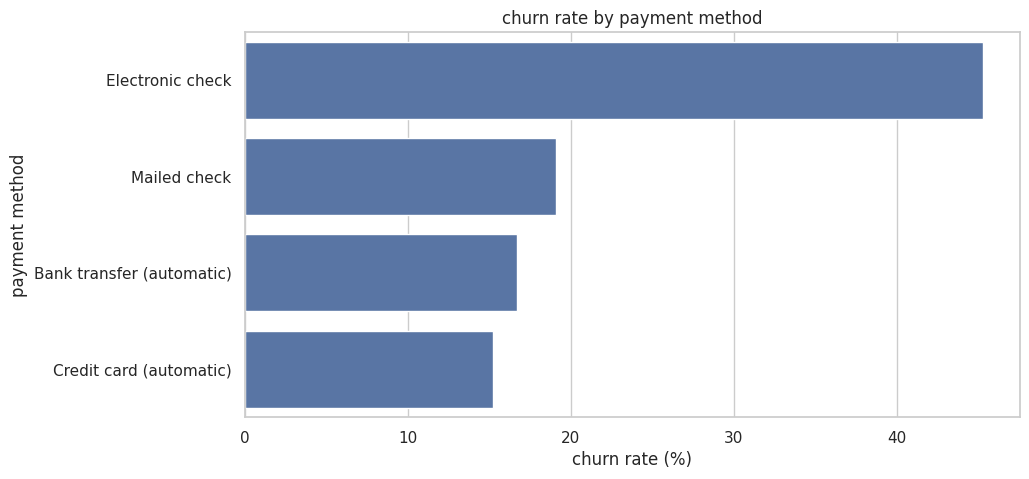

In [69]:
# 3) churn by payment method
payment_rate = (
    df_clean
    .groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_rate.values,
    y=payment_rate.index
)

plt.title("churn rate by payment method")
plt.xlabel("churn rate (%)")
plt.ylabel("payment method")
plt.show()

In [70]:
# 4) churn by tenure

# tenure group by tenure
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"
    ]
)

tenure_rate = (
    df_clean
    .groupby("TenureGroup", observed=True)["Churn"]
    .mean()
    * 100
)
display(tenure_rate)

,Churn
TenureGroup,
0-12 Months,47.438243
13-24 Months,28.710938
25-48 Months,20.388959
49+ Months,9.513176


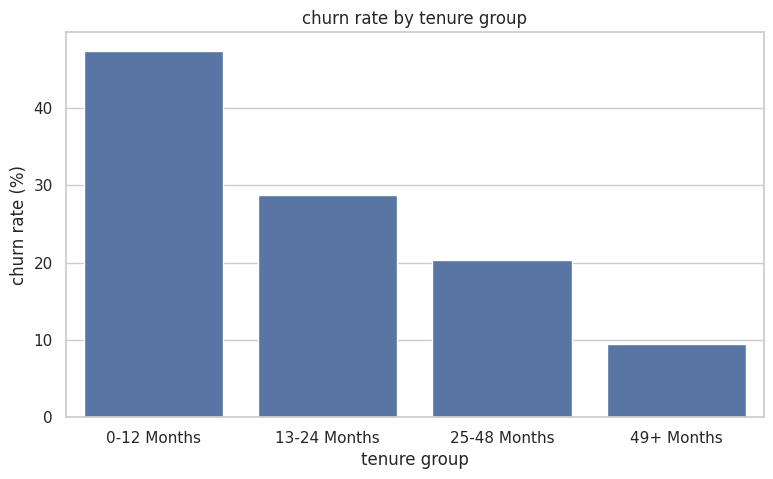

In [71]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_rate.index,
    y=tenure_rate.values
)

plt.title("churn rate by tenure group")
plt.xlabel("tenure group")
plt.ylabel("churn rate (%)")
plt.show()

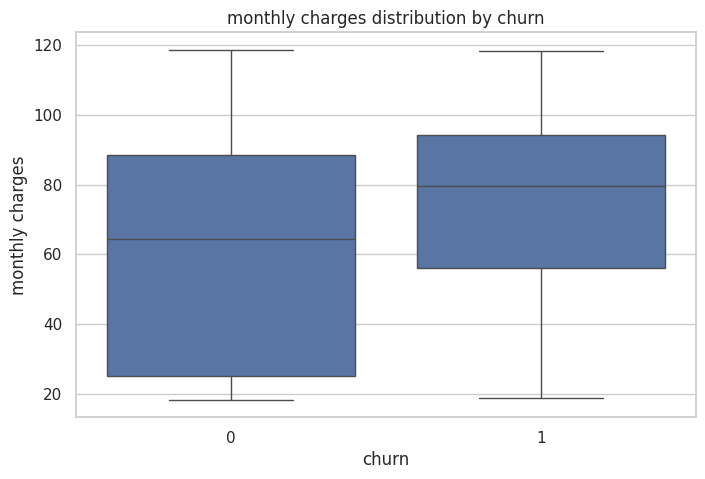

In [72]:
# 5) monthly charges vs churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("monthly charges distribution by churn")
plt.xlabel("churn")
plt.ylabel("monthly charges")

plt.show()

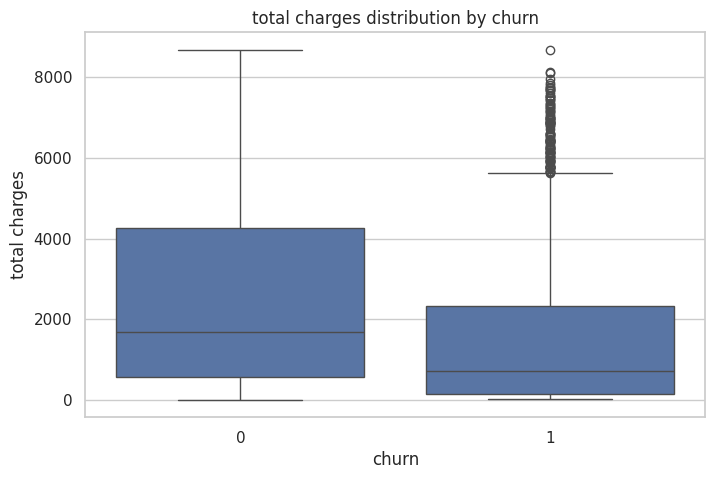

In [74]:
# 6) total charges vs churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="TotalCharges"
)

plt.title("total charges distribution by churn")
plt.xlabel("churn")
plt.ylabel("total charges")

plt.show()

## **5) Feature Enginering**

In [76]:
# 1) service count

service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_yes_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_yes_columns:
    df_clean[col + "_Binary"] = (
        df_clean[col] == "Yes"
    ).astype(int)

binary_service_cols = [
    col + "_Binary"
    for col in service_yes_columns
]

df_clean["ServiceCount"] = (
    df_clean[binary_service_cols]
    .sum(axis=1)
)

df_clean[[
    "tenure",
    "MonthlyCharges",
    "ServiceCount",
    "Churn"
]].head()

,tenure,MonthlyCharges,ServiceCount,Churn
0,1,29.85,1,0
1,34,56.95,3,0
2,2,53.85,3,1
3,45,42.30,3,0
4,2,70.70,1,1


In [79]:
# 2) charge group
df_clean["ChargeGroup"] = pd.cut(
    df_clean["MonthlyCharges"],
    bins=[-np.inf, 35, 70, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

charge_rate = (
    df_clean
    .groupby("ChargeGroup", observed=True)["Churn"]
    .mean()
    * 100
)

display(charge_rate)

,Churn
ChargeGroup,
Low,10.893372
Medium,23.942029
High,35.361429


## **6) Prepare Modelling Dataset**

In [80]:
# modelling data

model_df = df_clean.copy()

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [81]:
# remove analysis only columns

helper_columns = (
    ["TenureGroup", "ChargeGroup"]
    + binary_service_cols
)

X = X.drop(
    columns=helper_columns,
    errors="ignore"
)

print(X.shape)

(7043, 20)


In [82]:
display(X)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,7
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,6
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,1
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,2


In [83]:
# feature type

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## **7) preprocessing numeric & categorical columns**

In [84]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## **8) train test split**

In [88]:
# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (5634, 20)
Testing set : (1409, 20)


## **9) baseline model: logistic regressi**on

In [89]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [93]:
# evaluation function

def evaluate_model(model_name, y_true, y_pred, y_prob):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }

In [95]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

pd.DataFrame([logistic_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.738822,0.505172,0.783422,0.614256,0.841794


## **10) random forest**

In [96]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [97]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

pd.DataFrame([rf_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.789922,0.635417,0.489305,0.55287,0.824447


## **11) XGBoost**

In [98]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [99]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

pd.DataFrame([xgb_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.797729,0.650847,0.513369,0.573991,0.841644


## **12) Model Comparison**

In [100]:
results = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

results = results.sort_values(
    "ROC-AUC",
    ascending=False
)

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8418
2,XGBoost,0.7977,0.6508,0.5134,0.5740,0.8416
1,Random Forest,0.7899,0.6354,0.4893,0.5529,0.8244


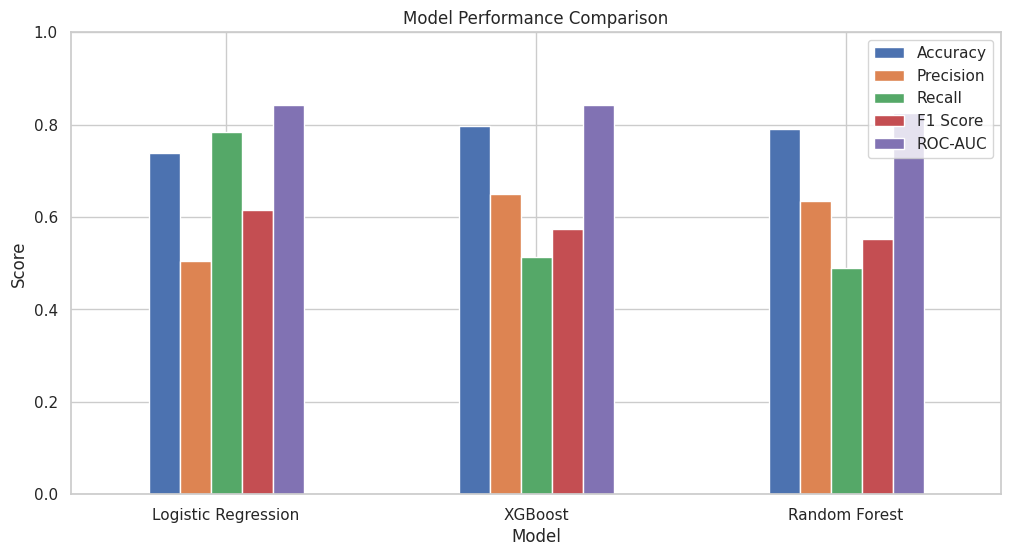

In [101]:
results_plot = results.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## **13) hyperparameter tuning**

In [102]:
# XGBoost tuning

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [103]:
param_grid = {
    "classifier__n_estimators": [
        200,
        300
    ],
    "classifier__max_depth": [
        3,
        4,
        5
    ],
    "classifier__learning_rate": [
        0.03,
        0.05,
        0.1
    ],
    "classifier__subsample": [
        0.8,
        1.0
    ]
}

In [104]:
# cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [105]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'ServiceCount']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imput...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.03, 0.05, 0.1],
                         'classifier__max_depth': [3, 4, 5],
                         'classifier__n_estimators': [200, 300],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [106]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}

Best CV ROC-AUC:
0.8498526584993945


In [108]:
# tuned model evaluation
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

y_prob_best = (
    best_model
    .predict_proba(X_test)[:, 1]
)

tuned_results = evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_best,
    y_prob_best
)

pd.DataFrame([tuned_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned XGBoost,0.801987,0.66436,0.513369,0.579186,0.847211


## **14) final model comparison**

In [109]:
final_results = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results,
    tuned_results
])

final_results = final_results.sort_values(
    "ROC-AUC",
    ascending=False
)

display(
    final_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Tuned XGBoost,0.8020,0.6644,0.5134,0.5792,0.8472
0,Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8418
2,XGBoost,0.7977,0.6508,0.5134,0.5740,0.8416
1,Random Forest,0.7899,0.6354,0.4893,0.5529,0.8244


## **15) classification report**


In [114]:
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "no churn",
            "churn"
        ]
    )
)

              precision    recall  f1-score   support

    no churn       0.84      0.91      0.87      1035
       churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



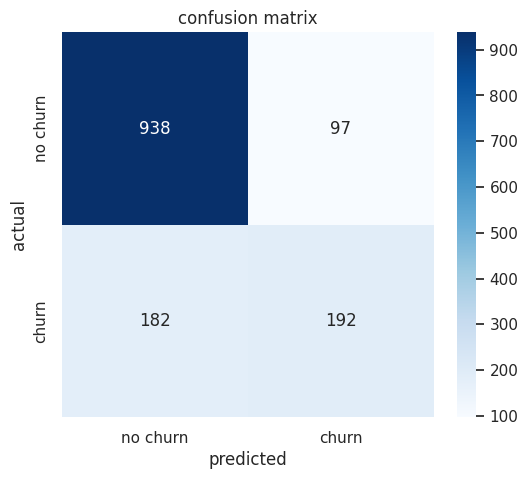

In [113]:
# conf matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "no churn",
        "churn"
    ],
    yticklabels=[
        "no churn",
        "churn"
    ]
)

plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

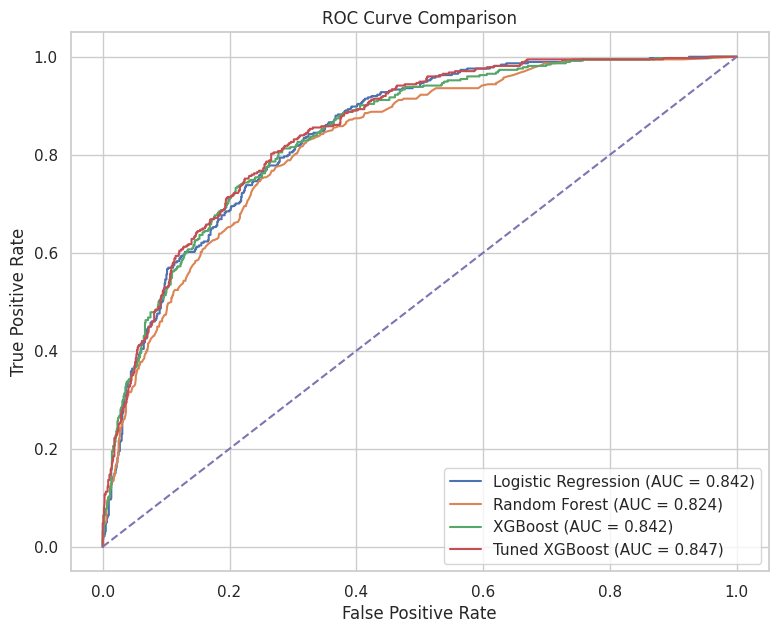

In [115]:
# ROC curve
models_probabilities = {
    "Logistic Regression": y_prob_logistic,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "Tuned XGBoost": y_prob_best
}

plt.figure(figsize=(9, 7))

for name, probabilities in models_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [116]:
# treshold analysis
thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_best >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)
display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.20,0.472059,0.858289,0.609108
1,0.25,0.501623,0.826203,0.624242
2,0.30,0.523297,0.780749,0.626609
3,0.35,0.559499,0.716578,0.628370
4,0.40,0.591346,0.657754,0.622785
5,0.45,0.639437,0.606952,0.622771
6,0.50,0.664360,0.513369,0.579186
7,0.55,0.696035,0.422460,0.525790
8,0.60,0.734463,0.347594,0.471869
9,0.65,0.760870,0.280749,0.410156


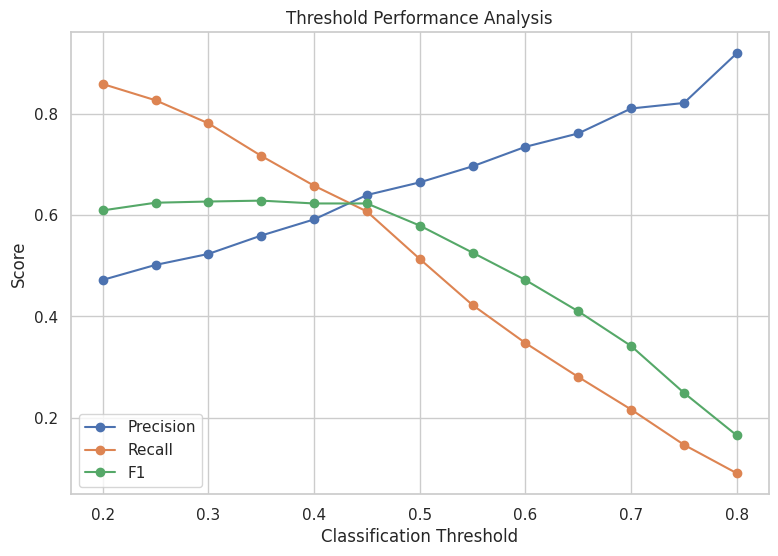

In [118]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Performance Analysis")
plt.legend()
plt.show()

## **16) Model Interpretation**

In [119]:
# permutation importance
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})
importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    importance_df.head(15)
)

,Feature,Importance
4,tenure,0.069936
14,Contract,0.054047
7,InternetService,0.039904
18,TotalCharges,0.003754
16,PaymentMethod,0.003652
15,PaperlessBilling,0.002337
13,StreamingMovies,0.002004
8,OnlineSecurity,0.001940
11,TechSupport,0.001681
5,PhoneService,0.001551


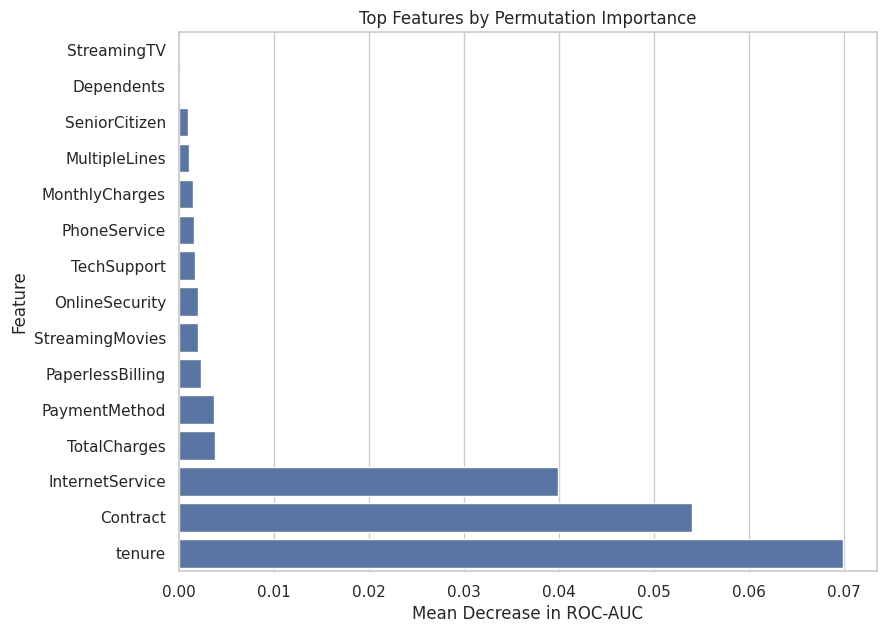

In [120]:
top_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title(
    "Top Features by Permutation Importance"
)
plt.xlabel(
    "Mean Decrease in ROC-AUC"
)
plt.ylabel("Feature")
plt.show()

## **17) predicted churn probability**

In [122]:
# predicted all customers
customer_predictions = X.copy()
customer_predictions["ActualChurn"] = y
customer_predictions["ChurnProbability"] = (
    best_model
    .predict_proba(X)[:, 1]
)

customer_predictions["PredictedChurn"] = (
    customer_predictions["ChurnProbability"] >= 0.5
).astype(int)
customer_predictions.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,ActualChurn,ChurnProbability,PredictedChurn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,0,0.687770,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,3,0,0.043230,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,3,1,0.384403,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,3,0,0.048591,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,0.662615,1


### **18) customer risk segmentation**

,count
RiskSegment,
Low Risk,4325
Medium Risk,1797
High Risk,921


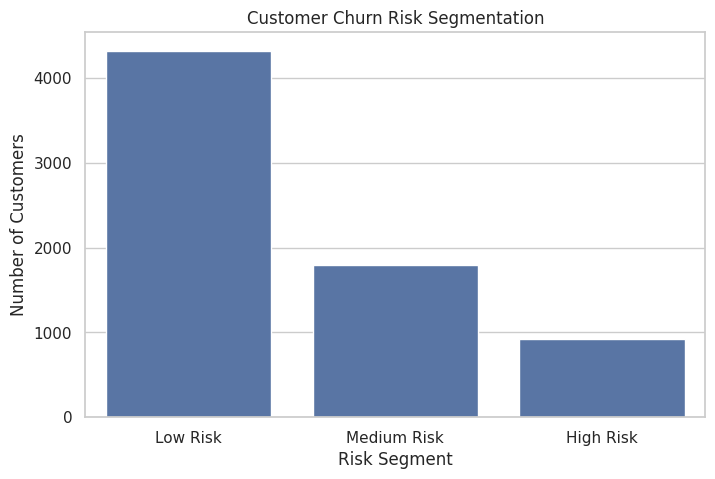

In [128]:
# risk segmentation
def assign_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

customer_predictions["RiskSegment"] = (
    customer_predictions["ChurnProbability"]
    .apply(assign_risk)
)

risk_distribution = (
    customer_predictions["RiskSegment"]
    .value_counts()
)
display(risk_distribution)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=customer_predictions,
    x="RiskSegment",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Customer Churn Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")
plt.show()



## **19) actual churn rate by risk segment**

In [129]:
risk_performance = (
    customer_predictions
    .groupby("RiskSegment")
    .agg(
        Customers=("ActualChurn", "count"),
        ActualChurnRate=("ActualChurn", "mean"),
        AvgChurnProbability=("ChurnProbability", "mean")
    )
)

risk_performance["ActualChurnRate"] *= 100
risk_performance["AvgChurnProbability"] *= 100
risk_performance = risk_performance.reindex([
    "Low Risk",
    "Medium Risk",
    "High Risk"
])
display(risk_performance)

,Customers,ActualChurnRate,AvgChurnProbability
RiskSegment,,,
Low Risk,4325,8.739884,9.812411
Medium Risk,1797,44.518642,43.759258
High Risk,921,75.027144,72.012413


## **20) high-risk by contract**

In [131]:
high_risk_contract = (
    high_risk
    .groupby("Contract")
    .agg(
        Customers=("ActualChurn", "count"),
        AvgChurnProbability=("ChurnProbability", "mean"),
        ActualChurnRate=("ActualChurn", "mean")
    )
)

high_risk_contract["AvgChurnProbability"] *= 100
high_risk_contract["ActualChurnRate"] *= 100
display(
    high_risk_contract
    .sort_values(
        "AvgChurnProbability",
        ascending=False
    )
)

,Customers,AvgChurnProbability,ActualChurnRate
Contract,,,
Month-to-month,920,72.025314,75.0
One year,1,60.146351,100.0


## **21) high-risk by tenure**

In [132]:
high_risk["TenureGroup"] = pd.cut(
    high_risk["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"
    ]
)

high_risk_tenure = (
    high_risk
    .groupby(
        "TenureGroup",
        observed=True
    )
    .agg(
        Customers=("ActualChurn", "count"),
        AvgChurnProbability=("ChurnProbability", "mean"),
        ActualChurnRate=("ActualChurn", "mean")
    )
)

high_risk_tenure["AvgChurnProbability"] *= 100
high_risk_tenure["ActualChurnRate"] *= 100
display(high_risk_tenure)

,Customers,AvgChurnProbability,ActualChurnRate
TenureGroup,,,
0-12 Months,807,72.839828,75.960347
13-24 Months,104,66.523575,66.346154
25-48 Months,10,62.323971,90.000000


## **22) high-risk by monthly charges**

In [133]:
high_risk["ChargeGroup"] = pd.cut(
    high_risk["MonthlyCharges"],
    bins=[-np.inf, 35, 70, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

high_risk_charge = (
    high_risk
    .groupby(
        "ChargeGroup",
        observed=True
    )
    .agg(
        Customers=("ActualChurn", "count"),
        AvgMonthlyCharges=("MonthlyCharges", "mean"),
        AvgChurnProbability=("ChurnProbability", "mean")
    )
)

high_risk_charge["AvgChurnProbability"] *= 100
display(high_risk_charge)

,Customers,AvgMonthlyCharges,AvgChurnProbability
ChargeGroup,,,
Low,21,27.114286,68.412636
Medium,126,58.546429,69.841698
High,774,85.855426,72.463455


## **23) high-risk by payment method**

In [134]:
high_risk_payment = (
    high_risk
    .groupby("PaymentMethod")
    .agg(
        Customers=("ActualChurn", "count"),
        AvgChurnProbability=("ChurnProbability", "mean")
    )
)

high_risk_payment["AvgChurnProbability"] *= 100
display(
    high_risk_payment
    .sort_values(
        "AvgChurnProbability",
        ascending=False
    )
)

,Customers,AvgChurnProbability
PaymentMethod,,
Electronic check,731,72.482231
Mailed check,90,71.098442
Credit card (automatic),48,69.433632
Bank transfer (automatic),52,69.370178


## **24) high-risk customer profile**

In [136]:
high_risk_profile = {
    "High-risk customers": len(high_risk),
    "Average tenure": high_risk["tenure"].mean(),
    "Average monthly charges": high_risk["MonthlyCharges"].mean(),
    "Average total charges": high_risk["TotalCharges"].mean(),
    "Average churn probability": high_risk["ChurnProbability"].mean()
}

profile_df = pd.DataFrame(
    high_risk_profile.items(),
    columns=["Metric", "Value"]
)
display(profile_df)

,Metric,Value
0,High-risk customers,921.000000
1,Average tenure,5.630836
2,Average monthly charges,80.779967
3,Average total charges,501.186156
4,Average churn probability,0.720124


## **25) compare high risk vs low risk**

In [137]:
risk_comparison = (
    customer_predictions
    .groupby("RiskSegment")
    .agg(
        Customers=("ActualChurn", "count"),
        AvgTenure=("tenure", "mean"),
        AvgMonthlyCharges=("MonthlyCharges", "mean"),
        AvgTotalCharges=("TotalCharges", "mean"),
        AvgServiceCount=("ServiceCount", "mean"),
        ActualChurnRate=("ActualChurn", "mean"),
        AvgChurnProbability=("ChurnProbability", "mean")
    )
)

risk_comparison["ActualChurnRate"] *= 100
risk_comparison["AvgChurnProbability"] *= 100
risk_comparison = risk_comparison.reindex([
    "Low Risk",
    "Medium Risk",
    "High Risk"
])
display(risk_comparison)

,Customers,AvgTenure,AvgMonthlyCharges,AvgTotalCharges,AvgServiceCount,ActualChurnRate,AvgChurnProbability
RiskSegment,,,,,,,
Low Risk,4325,43.007861,58.180474,2844.711133,3.571329,8.739884,9.812411
Medium Risk,1797,20.475793,72.391597,1831.497273,3.126322,44.518642,43.759258
High Risk,921,5.630836,80.779967,501.186156,2.845820,75.027144,72.012413


## **26) export customer risk list**

In [138]:
# export risk segmentation
risk_output = customer_predictions.copy()
risk_output = risk_output.sort_values(
    "ChurnProbability",
    ascending=False
)

risk_output.to_csv(
    "customer_churn_risk_predictions.csv",
    index=False
)
print(
    "File exported successfully:"
    " customer_churn_risk_predictions.csv"
)

File exported successfully: customer_churn_risk_predictions.csv


## **27) business insight**

In [139]:
total_customers = len(customer_predictions)

high_risk_count = (
    customer_predictions["RiskSegment"]
    .eq("High Risk")
    .sum()
)

medium_risk_count = (
    customer_predictions["RiskSegment"]
    .eq("Medium Risk")
    .sum()
)

low_risk_count = (
    customer_predictions["RiskSegment"]
    .eq("Low Risk")
    .sum()
)

high_risk_percentage = (
    high_risk_count / total_customers * 100
)

medium_risk_percentage = (
    medium_risk_count / total_customers * 100
)

low_risk_percentage = (
    low_risk_count / total_customers * 100
)

print(f"Total customers     : {total_customers:,}")
print(
    f"High-risk customers : "
    f"{high_risk_count:,} "
    f"({high_risk_percentage:.2f}%)"
)
print(
    f"Medium-risk         : "
    f"{medium_risk_count:,} "
    f"({medium_risk_percentage:.2f}%)"
)
print(
    f"Low-risk            : "
    f"{low_risk_count:,} "
    f"({low_risk_percentage:.2f}%)"
)

Total customers     : 7,043
High-risk customers : 921 (13.08%)
Medium-risk         : 1,797 (25.51%)
Low-risk            : 4,325 (61.41%)


## **27) Identify Highest-Risk Categories**

In [141]:
# contract
contract_summary = (
    df_clean
    .groupby("Contract")
    .agg(
        Customers=("Churn", "count"),
        ChurnRate=("Churn", "mean")
    )
)

contract_summary["ChurnRate"] *= 100
highest_contract = (
    contract_summary["ChurnRate"]
    .idxmax()
)
highest_contract_rate = (
    contract_summary["ChurnRate"]
    .max()
)
print(
    f"Contract category with the highest observed churn rate: "
    f"{highest_contract} "
    f"({highest_contract_rate:.2f}%)"
)

Contract category with the highest observed churn rate: Month-to-month (42.71%)


In [142]:
# internet services
internet_summary = (
    df_clean
    .groupby("InternetService")
    .agg(
        Customers=("Churn", "count"),
        ChurnRate=("Churn", "mean")
    )
)

internet_summary["ChurnRate"] *= 100
highest_internet = (
    internet_summary["ChurnRate"]
    .idxmax()
)
highest_internet_rate = (
    internet_summary["ChurnRate"]
    .max()
)
print(
    f"Internet service category with the highest observed churn rate: "
    f"{highest_internet} "
    f"({highest_internet_rate:.2f}%)"
)

Internet service category with the highest observed churn rate: Fiber optic (41.89%)


In [143]:
# payment method
payment_summary = (
    df_clean
    .groupby("PaymentMethod")
    .agg(
        Customers=("Churn", "count"),
        ChurnRate=("Churn", "mean")
    )
)

payment_summary["ChurnRate"] *= 100
highest_payment = (
    payment_summary["ChurnRate"]
    .idxmax()
)
highest_payment_rate = (
    payment_summary["ChurnRate"]
    .max()
)
print(
    f"Payment method category with the highest observed churn rate: "
    f"{highest_payment} "
    f"({highest_payment_rate:.2f}%)"
)

Payment method category with the highest observed churn rate: Electronic check (45.29%)


In [144]:
print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"\n1. Customer Risk Distribution"
)

print(
    f"The model identifies {high_risk_count:,} customers "
    f"({high_risk_percentage:.2f}%) as high-risk, "
    f"{medium_risk_count:,} ({medium_risk_percentage:.2f}%) "
    f"as medium-risk, and "
    f"{low_risk_count:,} ({low_risk_percentage:.2f}%) "
    f"as low-risk."
)

print(
    f"\n2. Contract Risk"
)

print(
    f"{highest_contract} customers show the highest observed "
    f"churn rate among contract categories, at "
    f"{highest_contract_rate:.2f}%."
)

print(
    f"\n3. Internet Service Risk"
)

print(
    f"{highest_internet} customers show the highest observed "
    f"churn rate among internet service categories, at "
    f"{highest_internet_rate:.2f}%."
)

print(
    f"\n4. Payment Method Risk"
)

print(
    f"{highest_payment} customers show the highest observed "
    f"churn rate among payment method categories, at "
    f"{highest_payment_rate:.2f}%."
)

BUSINESS INSIGHTS

1. Customer Risk Distribution
The model identifies 921 customers (13.08%) as high-risk, 1,797 (25.51%) as medium-risk, and 4,325 (61.41%) as low-risk.

2. Contract Risk
Month-to-month customers show the highest observed churn rate among contract categories, at 42.71%.

3. Internet Service Risk
Fiber optic customers show the highest observed churn rate among internet service categories, at 41.89%.

4. Payment Method Risk
Electronic check customers show the highest observed churn rate among payment method categories, at 45.29%.
